In [3]:
%pwd

'/Users/nad/hse/semester08/mobiraph/notebooks'

In [4]:
import config

from tqdm import tqdm
import warnings
import os
from hyena_dna.standalone_hyenadna import HyenaDNAModel
import torch
import pickle
import pandas as pd
import numpy as np
import re
import io
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, make_scorer, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier


os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
os.chdir(config.DIR_ROOT)

/Users/nad/miniconda3/envs/mobiraph/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/nad/miniconda3/envs/mobiraph/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/nad/miniconda3/envs/mobiraph/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/nad/miniconda3/envs/mobiraph/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/nad/miniconda3/envs/mobiraph/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/nad/miniconda3/envs/mobiraph/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/nad/miniconda3/envs/mobiraph/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be

In [5]:
from scripts.n10_classification_table_nice import plot_classification_report

In [6]:
%config InlineBackend.figure_format = 'retina'

# Logistic Regression

In [10]:
name_to_embedding = {}
name_to_type = {}

path_to_hyena_embedding = '/Users/nad/hse/semester08/mobiraph/data/n19_hyena_models/hyena_embeddings_1024_and_types.pkl'

def load_pickle_torch_cpu(path):
    orig = torch.storage._load_from_bytes
    try:
        torch.storage._load_from_bytes = lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        with open(path, 'rb') as f:
            return pickle.load(f)
    finally:
        torch.storage._load_from_bytes = orig

data = load_pickle_torch_cpu(path_to_hyena_embedding)
name_to_embedding = data['embeddings']

import json

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/hierarchy_sequences_02_ltr_correction.json', 'r', encoding='utf-8') as file:
    meta = json.load(file)

for class_name, class_dict in meta.items():
    for seq in class_dict["sequences"]:
        name_to_type[seq] = class_name

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/id_train.txt', 'r', encoding='utf-8') as file:
    names_train = [line.strip() for line in file]

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/id_test.txt', 'r', encoding='utf-8') as file:
    names_test = [line.strip() for line in file]

print(data)

train_filtered = [name for name in names_train
                  if name in name_to_embedding and name in name_to_type]

X_train = np.array([name_to_embedding[name] for name in train_filtered])
y_train = np.array([name_to_type[name] for name in train_filtered])

print('shape X_train', X_train.shape, 'shape y_train', y_train.shape)


test_filtered = [name for name in names_test
                 if name in name_to_embedding and name in name_to_type]

X_test = np.array([name_to_embedding[name] for name in test_filtered])
y_test = np.array([name_to_type[name] for name in test_filtered])

print('shape X_test', X_test.shape, 'shape y_test', y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Фиксированная модель без подбора параметров
model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver="lbfgs",
    penalty="l2",
    class_weight="balanced",
    verbose=1
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average="macro"))

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



shape X_train (95714, 1024) shape y_train (95714,)
shape X_test (23421, 1024) shape y_test (23421,)
Accuracy: 0.8677255454506639
F1-macro: 0.836260928913951


Accuracy: 0.8677255454506639


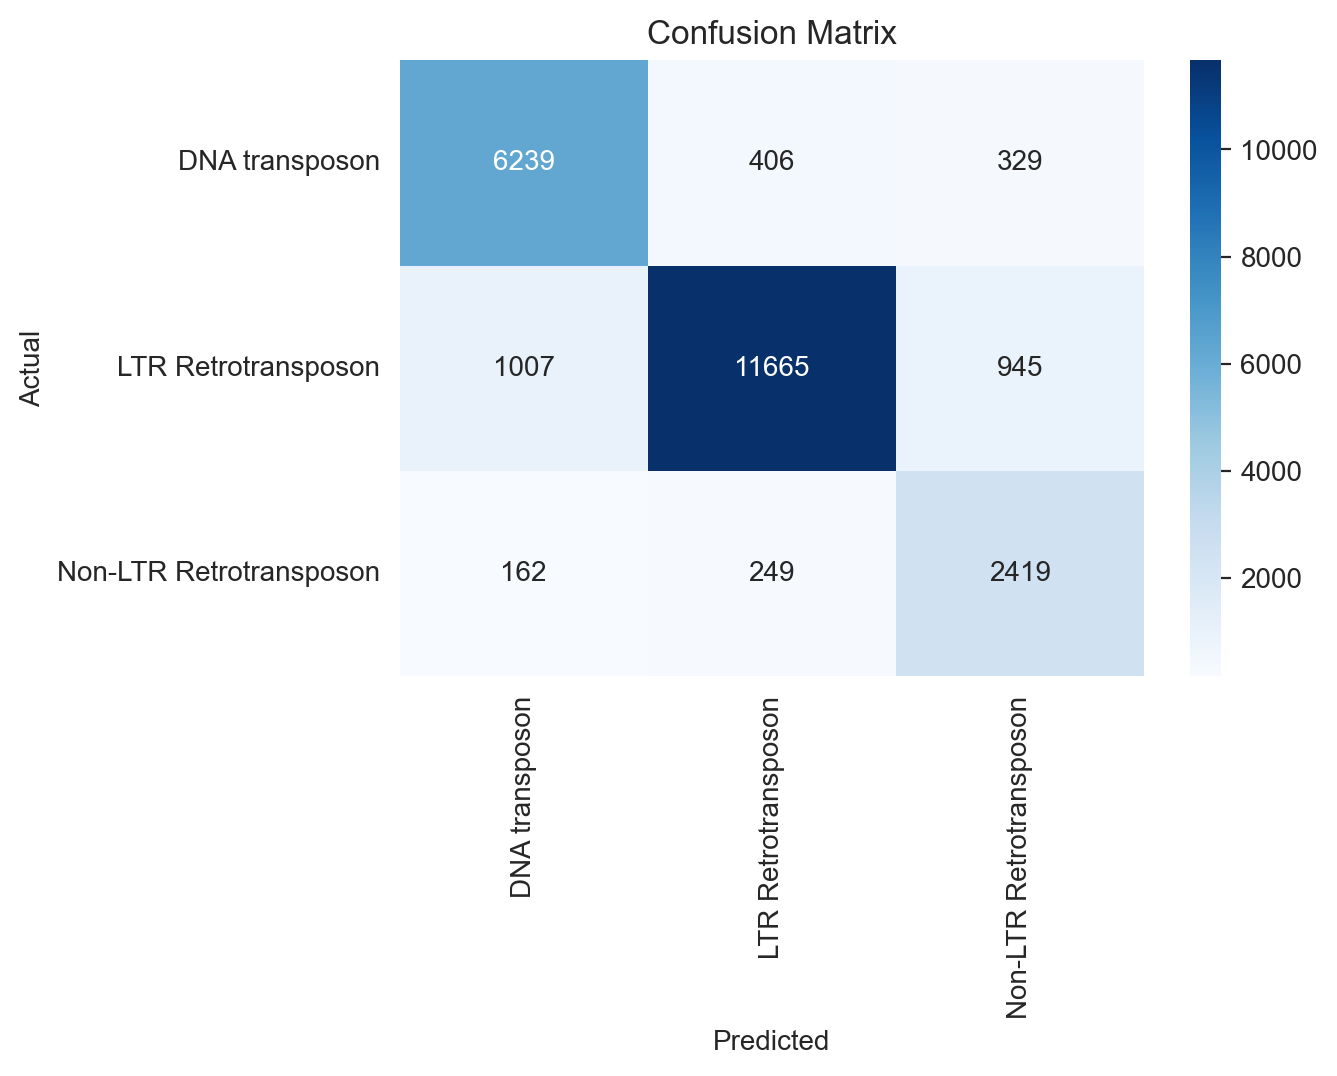

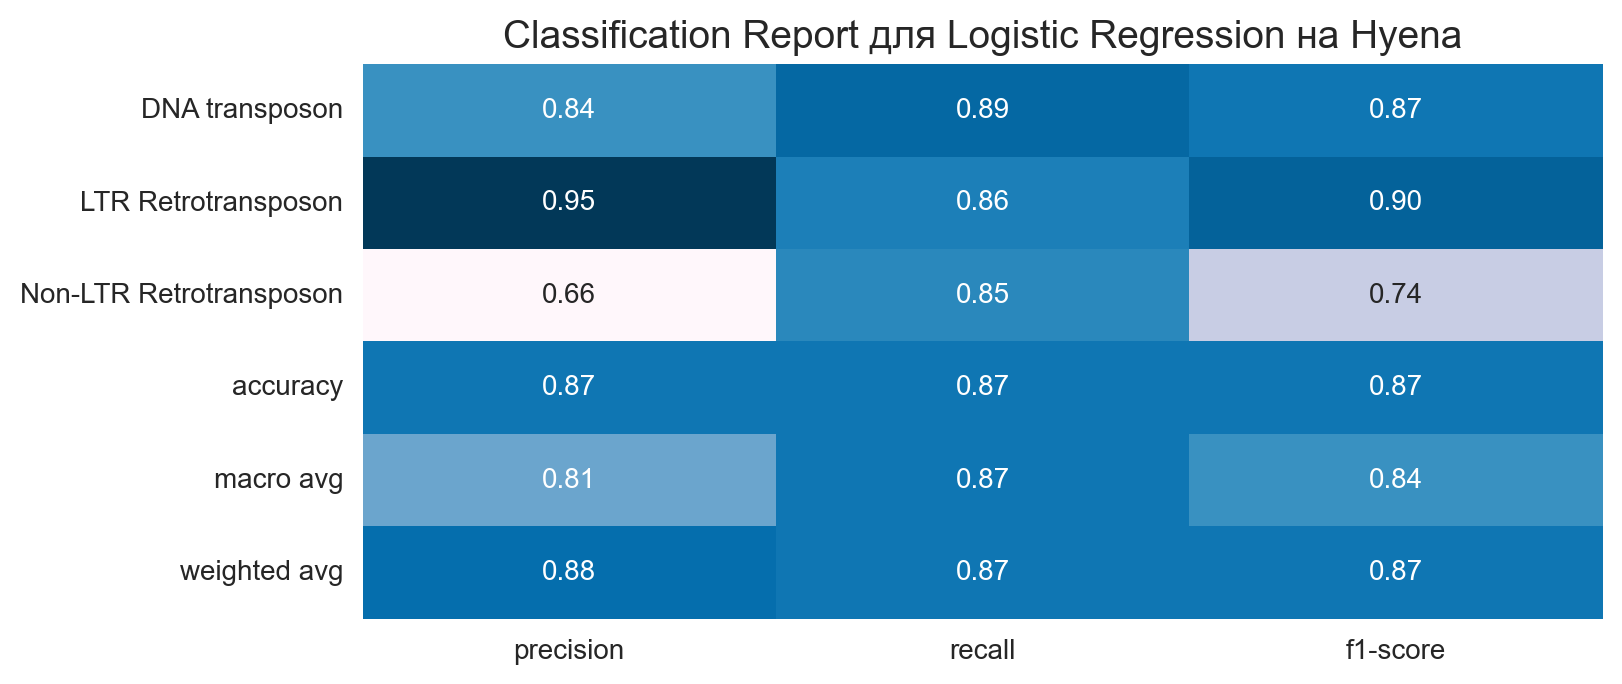

In [12]:
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred, title='Classification Report для Logistic Regression на Hyena')

In [17]:
import io
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

name_to_embedding = {}
name_to_type = {}

path_to_hyena_embedding = '/Users/nad/hse/semester08/mobiraph/data/n19_hyena_models/hyena_embeddings_1024_and_types.pkl'

def load_pickle_torch_cpu(path):
    orig = torch.storage._load_from_bytes
    try:
        torch.storage._load_from_bytes = lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        with open(path, 'rb') as f:
            return pickle.load(f)
    finally:
        torch.storage._load_from_bytes = orig

data = load_pickle_torch_cpu(path_to_hyena_embedding)
name_to_embedding = data['embeddings']

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/hierarchy_sequences_02_ltr_correction.json', 'r', encoding='utf-8') as file:
    meta = json.load(file)

for class_name, class_dict in meta.items():
    for seq in class_dict["sequences"]:
        name_to_type[seq] = class_name

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/id_train.txt', 'r', encoding='utf-8') as file:
    names_train = [line.strip() for line in file]

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/id_test.txt', 'r', encoding='utf-8') as file:
    names_test = [line.strip() for line in file]

train_filtered = [name for name in names_train if name in name_to_embedding and name in name_to_type]
test_filtered = [name for name in names_test if name in name_to_embedding and name in name_to_type]

X_train = np.array([name_to_embedding[name] for name in train_filtered], dtype=np.float32)
y_train = np.array([name_to_type[name] for name in train_filtered])

X_test = np.array([name_to_embedding[name] for name in test_filtered], dtype=np.float32)
y_test = np.array([name_to_type[name] for name in test_filtered])

print('shape X_train', X_train.shape, 'shape y_train', y_train.shape)
print('shape X_test', X_test.shape, 'shape y_test', y_test.shape)

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# Кодирование меток
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
input_dim = X_train_scaled.shape[1]

# Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmbeddingDataset(X_train_scaled, y_train_enc)
test_dataset = EmbeddingDataset(X_test_scaled, y_test_enc)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Transformer classifier
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=256, nhead=8, num_layers=3, dim_feedforward=512, dropout=0.1):
        super().__init__()

        # Проецируем исходный embedding в размерность transformer
        self.input_proj = nn.Linear(input_dim, d_model)

        # Будем разбивать embedding на "токены" по 1 позиции
        # seq_len = 1, поэтому это скорее Transformer-блок поверх embedding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [batch, input_dim]
        x = self.input_proj(x)          # [batch, d_model]
        x = x.unsqueeze(1)              # [batch, 1, d_model]
        x = self.transformer(x)         # [batch, 1, d_model]
        x = x[:, 0, :]                  # [batch, d_model]
        x = self.norm(x)
        logits = self.classifier(x)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
    d_model=256,
    nhead=8,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Обучение
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, loss={avg_loss:.4f}")

# Оценка
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

all_preds_labels = label_encoder.inverse_transform(all_preds)
all_true_labels = label_encoder.inverse_transform(all_true)

print("Accuracy:", accuracy_score(all_true_labels, all_preds_labels))
print("F1-macro:", f1_score(all_true_labels, all_preds_labels, average="macro"))

shape X_train (95714, 1024) shape y_train (95714,)
shape X_test (23421, 1024) shape y_test (23421,)
Epoch 1/5, loss=0.4256
Epoch 2/5, loss=0.3115
Epoch 3/5, loss=0.2752
Epoch 4/5, loss=0.2512
Epoch 5/5, loss=0.2394
Accuracy: 0.8802356859228897
F1-macro: 0.8375934458858131


Accuracy: 0.8802356859228897


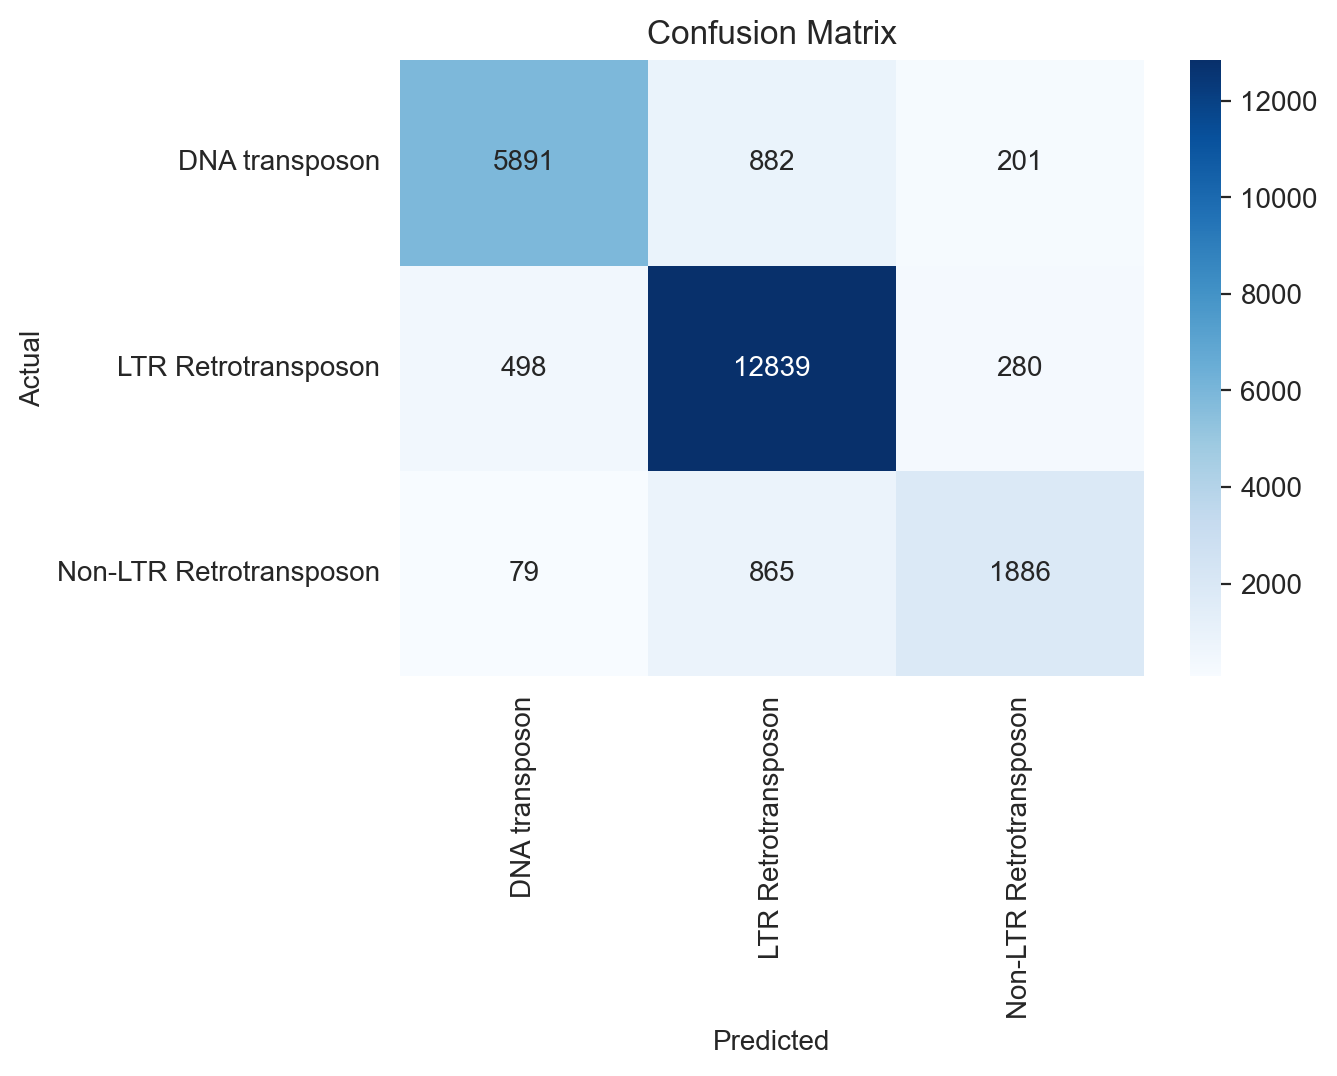

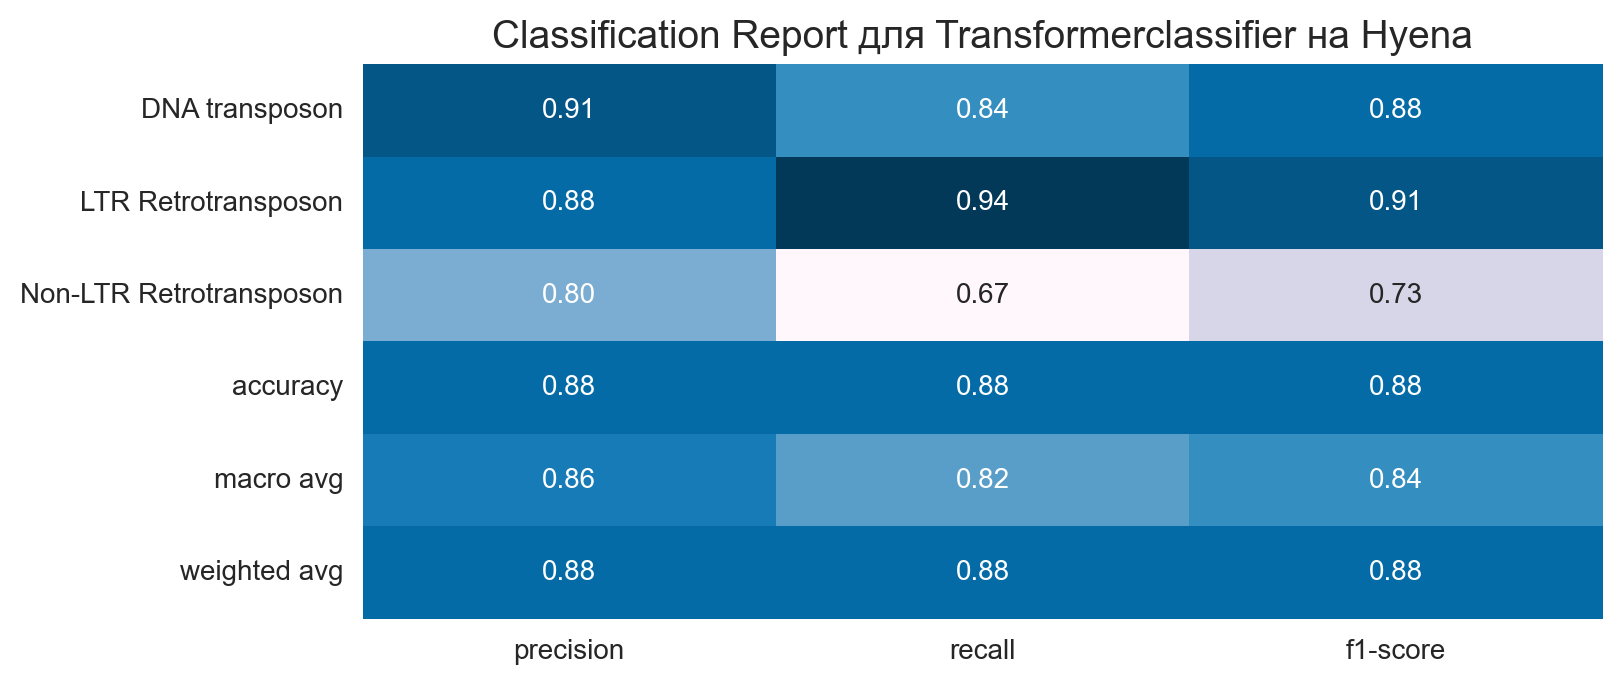

In [19]:
print("Accuracy:", accuracy_score(all_true_labels, all_preds_labels))
class_names = sorted(list(set(all_true_labels) | set(all_preds_labels)))
cm = confusion_matrix(all_true_labels, all_preds_labels, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(all_true_labels, all_preds_labels, title='Classification Report для Transformerclassifier на Hyena')

In [8]:
name_to_embedding = {}
name_to_type = {}
path_to_hyena_embedding = os.path.join(config.DIR_INCEST_MANY, '/Users/nad/hse/semester08/mobiraph/data/n19_hyena_models/hyena_embeddings_1024_and_types.pkl')
# with open(path_to_hyena_embedding, "rb") as f:
#     data = pickle.load(f)

def load_pickle_torch_cpu(path):
    orig = torch.storage._load_from_bytes
    try:
        torch.storage._load_from_bytes = lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        with open(path, 'rb') as f:
            return pickle.load(f)
    finally:
        torch.storage._load_from_bytes = orig

data = load_pickle_torch_cpu(path_to_hyena_embedding)


name_to_embedding = data['embeddings']


# path_to_filtered = os.path.join(config.DIR_INCEST_MANY, 'repbase_filtered.csv')
# df_filtered = pd.read_csv(path_to_filtered)
# names = list(df_filtered['name'])

import json

with open('/Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/hierarchy_sequences_02_ltr_correction.json', 'r', encoding='utf-8') as file:
    meta = json.load(file)

for class_name, class_dict in meta.items():
    for seq in class_dict["sequences"]:
        name_to_type[seq] = class_name

names = list(name_to_type.keys())

print(name_to_type)



X = np.array([name_to_embedding[name] for name in names])
y = np.array([name_to_type[name] for name in names])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "solver": ["lbfgs"],
    "penalty": ["l2"],
    "multi_class": ["auto"],
    "class_weight": ["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

gs = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



ValueError: Invalid parameter 'multi_class' for estimator LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred, title='Classification Report для Logistic Regression на Hyena')

In [ ]:
with open(config.FILE_MODEL_HYENA_LOGREG_V0, "wb") as f:
    pickle.dump(best_model, f)

print(f"Модель сохранена в {config.FILE_MODEL_HYENA_LOGREG_V0}")

In [ ]:
# восстановим индексы тестовой выборки тем же split'ом
idx = np.arange(len(y))
_, test_idx = train_test_split(idx, test_size=0.2, random_state=1, stratify=y)
names_test = np.array(names)[test_idx]

# напечатаем по одному корректному примеру на класс
y_pred = best_model.predict(X_test)
correct = (y_test == y_pred)
for cls in class_names:
    i = np.where((y_test == cls) & correct)[0]
    print(f"{cls}: {names_test[i[0]] if i.size else 'нет корректных'}")

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "kernel": ["linear", "rbf"],
    "class_weight": ["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

gs = GridSearchCV(
    estimator=SVC(max_iter=1000),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    verbose=0
)

gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred, title='Classification Report для SVM на Hyena')

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
X = np.array([np.asarray(name_to_embedding[n], dtype=float).ravel() for n in names])
y_types = np.array([name_to_type[n] for n in names])

X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=1, random_state=42)
X_pca = pca.fit_transform(X_std)
X_pca

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "solver": ["lbfgs"],
    "penalty": ["l2"],
    "multi_class": ["auto"],
    "class_weight": ["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

gs = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "solver": ["lbfgs"],
    "penalty": ["l2"],
    "multi_class": ["auto"],
    "class_weight": ["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

gs = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred)

## RandomForestClassifier

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "n_estimators": [100, 200],         # число деревьев
    "max_depth": [None, 10, 20],         # глубина деревьев
    "min_samples_split": [2, 5, 10],         # минимальное число образцов для разбиения
    "min_samples_leaf": [2, 4],           # минимальное число образцов в листе
    "class_weight": ["balanced", None]       # балансировка классов
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

# GridSearchCV
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1, n_jobs=-1),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)


gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "n_estimators": [100, 200],         # число деревьев
    "max_depth": [None, 10, 20],         # глубина деревьев
    "min_samples_split": [2, 5, 10],         # минимальное число образцов для разбиения
    "min_samples_leaf": [2, 4],           # минимальное число образцов в листе
    "class_weight": ["balanced", None]       # балансировка классов
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

# GridSearchCV
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1, n_jobs=-1),
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)


gs.fit(X_train, y_train)

print("Лучшие параметры:", gs.best_params_)
print("Лучшая CV F1-macro:", gs.best_score_)

best_model = gs.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
class_names = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=class_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plot_classification_report(y_test, y_pred)